# MobileNet V2 Model

In [62]:
# 1. Install Kaggle CLI
!pip install -q kaggle

In [63]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [64]:
# Unzip the images
!unzip -qn brain-tumor-mri-dataset.zip -d brain_tumor_data

In [65]:
# Check the directory structure
print("Training data:")
!cd brain_tumor_data && cd Training && ls
print("\nTesting data:")
!cd brain_tumor_data && cd Testing && ls

Training data:
glioma	meningioma  notumor  pituitary

Testing data:
glioma	meningioma  notumor  pituitary


In [66]:
import getpass

github_token = getpass.getpass("Enter github token to clone the repository: ")

# Cloning the repo
!git clone https://{github_token}@github.com/Dini-s/brain-tumour-mri-classification.git

fatal: destination path 'brain-tumour-mri-classification' already exists and is not an empty directory.


In [67]:
# add the path to the cloned repo to sys.path
import sys
sys.path.append('brain-tumour-mri-classification')

#importing the modules within src folder
from src.dataset import get_dataloaders
from src.utils import confusion_matrix, print_metrics, plot_confusion_matrix, plot_learning_curves, evaluate_model
from src.transforms import train_transforms, val_test_transforms

#importing the required libraries
import torch
import torch.nn as nn
import torch.optim as optimizations
import torchvision.models as models
import time
from pathlib import Path

# <h3> Settings for the whole notebook <h3>

In [68]:
DATA_DIR = '/content/brain_tumor_data'
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 4
LR_PHASE1 = 0.001
LR_PHASE2 = 0.0001
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 15
CHECKPOINT_DIR = Path('/content/mobilenetv2_best.pth')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# <h3> Loading Data <h3>

In [69]:
training, validation, test = get_dataloaders(DATA_DIR, BATCH_SIZE)

image, label = next(iter(training))

print(f"Image shape: {image.shape}")
print(f"Label: {label}")

print(f"Number of images in the batch: {len(image)}")

Train:      4,480 images
Validation: 1,120 images
Test:       1,600 images
Classes:    ['glioma', 'meningioma', 'notumor', 'pituitary']
Image shape: torch.Size([32, 3, 224, 224])
Label: tensor([0, 3, 0, 0, 3, 0, 2, 0, 0, 1, 2, 2, 0, 0, 1, 2, 1, 3, 2, 3, 3, 0, 3, 1,
        0, 3, 1, 0, 1, 2, 1, 0])
Number of images in the batch: 32


# <h3>Building the Model</h3>

importing the model and replacing the classifier layer with a new layer. The new layer has 4 output classes

In [70]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT, progress=True)

classifier = model.classifier
input_features = classifier[1].in_features

# setting the manula seed
torch.manual_seed(SEED)

# new layer with 4 output classes
classifier[1] = nn.Linear(in_features=input_features, out_features=NUM_CLASSES, bias=True)

print(classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


counting the number of trainable parameters in the model

In [71]:
global COUNT

def count_parameters(model):
    COUNT = 0
    for parameters in model.parameters():
        if parameters.requires_grad:
            COUNT += parameters.numel()

    print(f"Total number of trainable parameters: {COUNT}")

count_parameters(model)

Total number of trainable parameters: 2228996


<b>Running the model on a batch of images in evaluation mode and without gradients</b>

In [72]:
# Moving the model and data to device
moved_model = model.to(DEVICE)
moved_images_batch = image.to(DEVICE)
moved_labels = label.to(DEVICE)
# 1 test forward pass
with torch.no_grad():
    moved_model.eval()
    output = moved_model(moved_images_batch)

<b>Calculating the loss</b>

In [73]:
loss_function = nn.CrossEntropyLoss()
loss = loss_function(output, moved_labels)
print(f"Loss: {loss.item()}")

Loss: 1.3961381912231445


# <b>Training</b>

<b>Training will be done in 2 phases. In first phase, we will freeze the feature extractor and only train the classifier.</b>

<b>Freezing the feature extractor</b>

In [74]:
for parameters in moved_model.features.parameters():
    parameters.requires_grad = False # Freezing the feature extractor

count_parameters(moved_model)

Total number of trainable parameters: 5124


In [75]:
criterion = nn.CrossEntropyLoss()
optimizer = optimizations.Adam(moved_model.classifier.parameters(), LR_PHASE1)

<b>Function to train the model for one epoch</b>

In [76]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.to(device)
    model.train()

    total_training_loss = 0.0
    number_of_images = 0
    total_correct_predictions = 0

    for images, labels in loader:

        print("Processing Batch...")

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(images)

        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        number_of_images += images.size(0)

        total_training_loss_per_batch = loss.item() * images.size(0)

        print(f"Total training loss for batch: {total_training_loss_per_batch}")

        total_training_loss += total_training_loss_per_batch

        predictions = output.argmax(dim=1)

        total_correct_for_batch = (labels == predictions).sum().item()

        total_correct_predictions += total_correct_for_batch

    print("Finished training epoch.")

    averge_training_loss = total_training_loss / number_of_images
    accuracy = (total_correct_predictions / number_of_images) * 100

    return averge_training_loss, accuracy

<b>Evaluate one epoch</b>

In [77]:
def evaluate_one_epoch(model, loader, criterion, device):

    model.to(device)
    with torch.no_grad():
        model.eval()

        total_training_loss = 0.0
        number_of_images = 0
        total_correct_predictions = 0

        for images, labels in loader:

            print("Processing Batch...")

            images, labels = images.to(device), labels.to(device)

            # Forward pass
            output = model(images)

            loss = criterion(output, labels)

            number_of_images += images.size(0)

            total_training_loss_per_batch = loss.item() * images.size(0)

            print(f"Total training loss for batch: {total_training_loss_per_batch}")

            total_training_loss += total_training_loss_per_batch

            predictions = output.argmax(dim=1)

            total_correct_for_batch = (labels == predictions).sum().item()

            total_correct_predictions += total_correct_for_batch

        print("Finished evaluation of epoch.")

        averge_training_loss = total_training_loss / number_of_images
        accuracy = (total_correct_predictions / number_of_images) * 100

        return averge_training_loss, accuracy

In [78]:
def train_model(model, training_loader, validation_loader, criterion, optimizer, device, epochs, checkpoint_path):

    train_losses = []
    validation_losses = []
    train_accuracies = []
    validation_accuracies = []

    best_validation_accuracy = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")

        train_loss, train_accuracy = train_one_epoch(model, training_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate_one_epoch(model, validation_loader, criterion, device)

        train_losses.append(train_loss)
        validation_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        validation_accuracies.append(val_accuracy)

        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

        if (val_accuracy > best_validation_accuracy):
            torch.save(model.state_dict(), checkpoint_path)
            best_validation_accuracy = val_accuracy

    end_time = time.time()
    phase1_seconds = end_time - start_time

    print(f"Phase 1 Time: {phase1_seconds:.2f} seconds")
    print(f"Best Validation Accuracy: {best_validation_accuracy:.2f}%")
    print(f"Number of epochs: {epochs}")

    return train_losses, validation_losses, train_accuracies, validation_accuracies, best_validation_accuracy, phase1_seconds

In [79]:
train_losses, validation_losses, train_accuracies, validation_accuracies, best_validation_accuracy, phase1_seconds = train_model(moved_model, training, validation, criterion, optimizer, DEVICE, EPOCHS_PHASE1, CHECKPOINT_DIR)

Epoch 1/10
Processing Batch...
Total training loss for batch: 44.92610168457031
Processing Batch...
Total training loss for batch: 44.21595764160156
Processing Batch...
Total training loss for batch: 43.84022521972656
Processing Batch...
Total training loss for batch: 41.749454498291016
Processing Batch...
Total training loss for batch: 42.24635314941406
Processing Batch...
Total training loss for batch: 39.60888671875
Processing Batch...
Total training loss for batch: 40.66501235961914
Processing Batch...
Total training loss for batch: 40.57438278198242
Processing Batch...
Total training loss for batch: 41.356327056884766
Processing Batch...
Total training loss for batch: 37.54343032836914
Processing Batch...
Total training loss for batch: 37.791351318359375
Processing Batch...
Total training loss for batch: 36.2286376953125
Processing Batch...
Total training loss for batch: 35.87625503540039
Processing Batch...
Total training loss for batch: 37.34139633178711
Processing Batch...
Tota

<b>Learning curve for the phase 1 (training only the classifier head)</b>

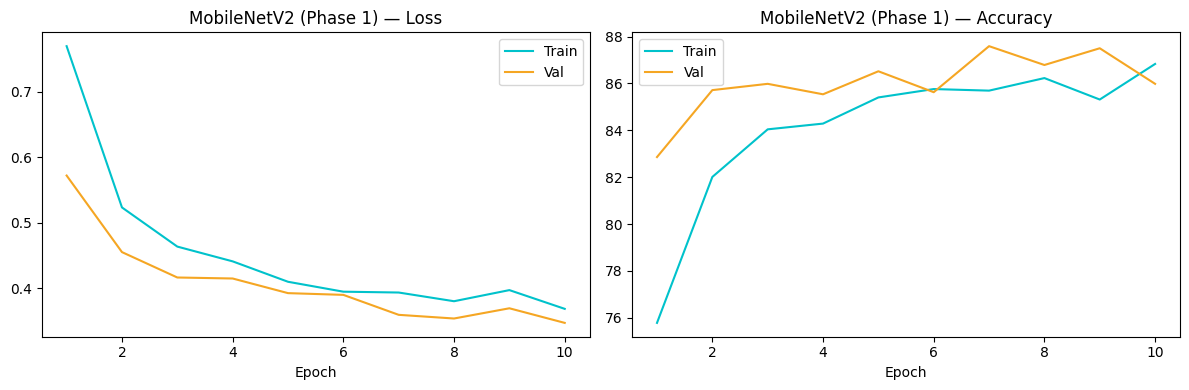

In [80]:
plot_learning_curves(train_losses, validation_losses, train_accuracies, validation_accuracies, "MobileNetV2 (Phase 1)")

# <h3>Phase 2: Fine-tuning</h3>

<b>In the second phase, the last 5 blocks of the feature extractor (features[14] to features[18]) are unfrozen and trained together with the classifier, using a smaller learning rate.</b>

<b>Loading the best model from phase 1</b>

In [81]:
moved_model.load_state_dict(torch.load(CHECKPOINT_DIR))

# checking the validation accuracy of the loaded model
phase1_loss, phase1_accuracy = evaluate_one_epoch(moved_model, validation, criterion, DEVICE)

print(f"Best Phase 1 Validation Accuracy: {phase1_accuracy:.2f}%")

Processing Batch...
Total training loss for batch: 8.464899063110352
Processing Batch...
Total training loss for batch: 4.142644882202148
Processing Batch...
Total training loss for batch: 8.084135055541992
Processing Batch...
Total training loss for batch: 10.479925155639648
Processing Batch...
Total training loss for batch: 8.019702911376953
Processing Batch...
Total training loss for batch: 8.459016799926758
Processing Batch...
Total training loss for batch: 14.64161491394043
Processing Batch...
Total training loss for batch: 8.15039348602295
Processing Batch...
Total training loss for batch: 9.87828540802002
Processing Batch...
Total training loss for batch: 11.500649452209473
Processing Batch...
Total training loss for batch: 12.275655746459961
Processing Batch...
Total training loss for batch: 13.035419464111328
Processing Batch...
Total training loss for batch: 13.565954208374023
Processing Batch...
Total training loss for batch: 10.911209106445312
Processing Batch...
Total trai

<b>Unfreezing the last 5 blocks of the feature extractor</b>

In [82]:
for parameters in moved_model.features[14:].parameters():
    parameters.requires_grad = True # Unfreezing the last 5 blocks

count_parameters(moved_model)

Total number of trainable parameters: 1686468


<b>New optimizer for phase 2 with the smaller learning rate</b>

In [83]:
trainable_parameters = []

for parameters in moved_model.parameters():
    if parameters.requires_grad:
        trainable_parameters.append(parameters)

optimizer_phase2 = optimizations.Adam(trainable_parameters, LR_PHASE2)

<b>Function to train phase 2. It also returns the history for the learning curves</b>

In [84]:
def train_model_phase2(model, training_loader, validation_loader, criterion, optimizer, device, epochs, checkpoint_path, best_validation_accuracy):

    train_losses = []
    validation_losses = []
    train_accuracies = []
    validation_accuracies = []

    best_epoch = 0

    start_time = time.time()

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")

        train_loss, train_accuracy = train_one_epoch(model, training_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate_one_epoch(model, validation_loader, criterion, device)

        train_losses.append(train_loss)
        validation_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        validation_accuracies.append(val_accuracy)

        print(f"Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

        if (val_accuracy > best_validation_accuracy):
            torch.save(model.state_dict(), checkpoint_path)
            best_validation_accuracy = val_accuracy
            best_epoch = epoch + 1

    end_time = time.time()
    phase2_seconds = end_time - start_time

    print(f"Phase 2 Time: {phase2_seconds:.2f} seconds")
    print(f"Best Validation Accuracy: {best_validation_accuracy:.2f}%")
    print(f"Best Epoch: {best_epoch}")
    print(f"Number of epochs: {epochs}")

    return train_losses, validation_losses, train_accuracies, validation_accuracies, phase2_seconds

In [85]:
train_losses, validation_losses, train_accuracies, validation_accuracies, phase2_seconds = train_model_phase2(moved_model, training, validation, criterion, optimizer_phase2, DEVICE, EPOCHS_PHASE2, CHECKPOINT_DIR, phase1_accuracy)

Epoch 1/15
Processing Batch...
Total training loss for batch: 8.258512496948242
Processing Batch...
Total training loss for batch: 11.786465644836426
Processing Batch...
Total training loss for batch: 8.994234085083008
Processing Batch...
Total training loss for batch: 9.398089408874512
Processing Batch...
Total training loss for batch: 7.461964130401611
Processing Batch...
Total training loss for batch: 12.254384994506836
Processing Batch...
Total training loss for batch: 8.847419738769531
Processing Batch...
Total training loss for batch: 14.933502197265625
Processing Batch...
Total training loss for batch: 6.704013824462891
Processing Batch...
Total training loss for batch: 19.21934700012207
Processing Batch...
Total training loss for batch: 13.353904724121094
Processing Batch...
Total training loss for batch: 13.599210739135742
Processing Batch...
Total training loss for batch: 12.073111534118652
Processing Batch...
Total training loss for batch: 17.134429931640625
Processing Batch

# <h3>Learning Curves</h3>

<b>Training and validation loss and accuracy during phase 2 (fine-tuning)</b>

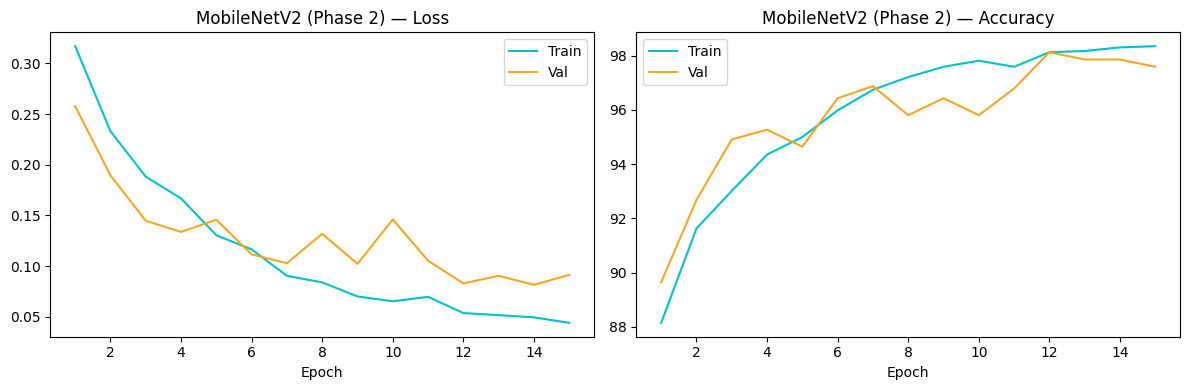

In [86]:
plot_learning_curves(train_losses, validation_losses, train_accuracies, validation_accuracies, "MobileNetV2 (Phase 2)")

# <h3>Test Evaluation</h3>

<b>Loading the best model and evaluating it once on the test set</b>

In [87]:
moved_model.load_state_dict(torch.load(CHECKPOINT_DIR))

start_time = time.time()

true_labels, predicted_labels, probabilities = evaluate_model(moved_model, test, DEVICE, "MobileNetV2")

end_time = time.time()
test_seconds = end_time - start_time

test_accuracy = (true_labels == predicted_labels).mean() * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Time: {test_seconds:.2f} seconds")

Test Accuracy: 94.31%
Test Time: 6.44 seconds


In [88]:
print_metrics(true_labels, predicted_labels, probabilities, "MobileNetV2")


Results for: MobileNetV2
              precision    recall  f1-score   support

      glioma       0.98      0.81      0.89       400
  meningioma       0.89      0.96      0.93       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600

ROC-AUC (OvR): 0.9860


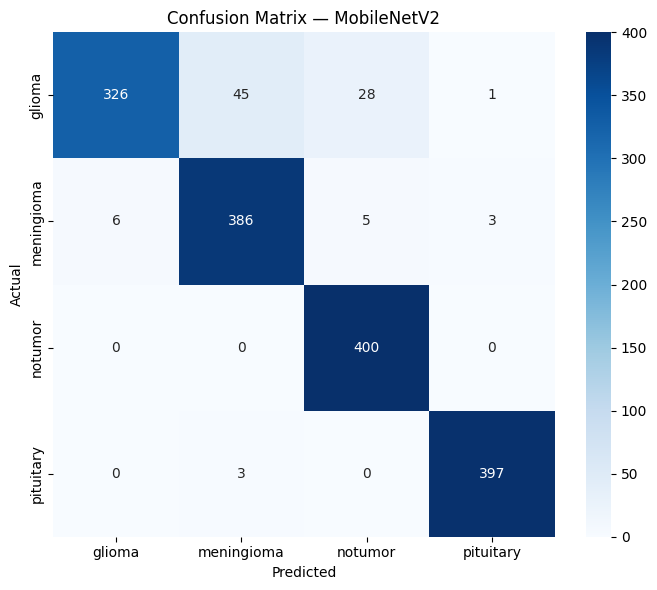

In [89]:
plot_confusion_matrix(true_labels, predicted_labels, "MobileNetV2")

# <h3>Efficiency</h3>

<b>Parameters, training time, inference time and model size</b>

In [90]:
total_parameters = 0
for parameters in moved_model.parameters():
    total_parameters += parameters.numel()

phase1_trainable_parameters = 0
for parameters in moved_model.classifier.parameters():
    phase1_trainable_parameters += parameters.numel()

phase2_trainable_parameters = 0
for parameters in trainable_parameters:
    phase2_trainable_parameters += parameters.numel()

phase1_percentage = phase1_trainable_parameters / total_parameters * 100
phase2_percentage = phase2_trainable_parameters / total_parameters * 100

inference_time_per_image = (test_seconds / len(true_labels)) * 1000
model_size_mb = (total_parameters * 4) / (1024 * 1024)

print(f"Total Parameters: {total_parameters}")
print(f"Trainable Parameters (Phase 1): {phase1_trainable_parameters} ({phase1_percentage:.2f}%)")
print(f"Trainable Parameters (Phase 2): {phase2_trainable_parameters} ({phase2_percentage:.2f}%)")
print(f"Phase 1 Time: {phase1_seconds:.2f} seconds ({phase1_seconds / EPOCHS_PHASE1:.2f} seconds per epoch)")
print(f"Phase 2 Time: {phase2_seconds:.2f} seconds ({phase2_seconds / EPOCHS_PHASE2:.2f} seconds per epoch)")
print(f"Total Training Time: {(phase1_seconds + phase2_seconds) / 60:.2f} minutes")
print(f"Inference Time per Image: {inference_time_per_image:.3f} ms")
print(f"Model Size: {model_size_mb:.2f} MB")

Total Parameters: 2228996
Trainable Parameters (Phase 1): 5124 (0.23%)
Trainable Parameters (Phase 2): 1686468 (75.66%)
Phase 1 Time: 316.07 seconds (31.61 seconds per epoch)
Phase 2 Time: 483.89 seconds (32.26 seconds per epoch)
Total Training Time: 13.33 minutes
Inference Time per Image: 4.025 ms
Model Size: 8.50 MB


<b>Checking the number of images per class in the training and validation sets (used in the report)</b>

In [91]:
training_class_counts = [0, 0, 0, 0]
for index in training.dataset.indices:
    training_class_counts[training.dataset.dataset.targets[index]] += 1

validation_class_counts = [0, 0, 0, 0]
for index in validation.dataset.indices:
    validation_class_counts[validation.dataset.dataset.targets[index]] += 1

print(f"Training images per class: {training_class_counts}")
print(f"Validation images per class: {validation_class_counts}")

Training images per class: [1115, 1123, 1111, 1131]
Validation images per class: [285, 277, 289, 269]


<b></b>